In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import random as rnd

## Monty Hall Problem

You are playing a TV game show and are shown 2 doors. One has a car behind it, the other a goat. What are your chances of picking the door with the car?


In [ ]:
tries = 1000
wins = 0

for n in range(tries):
    car_idx = rnd.randint(0,2)
    pick = rnd.randint(0,2)
    if pick == car_idx:
        wins +=1

print('chance of winning: ', wins/tries*100, '%')

chance of winning:  49.1 %


OK, now there are 3 doors: one with a car, two with goats. The game show host asks you to pick a door, but not to open it yet. Then the host opens one of the other two doors (that you did not pick) and that has a goat. The host offers you the opportunity to switch doors.

- One player decides to switch
- Another player prefers to stay with the previous choice
- Now a third player comes in who has not seen what happened earlier. They pick a door.
Which of the three players is most likely to win?


Simulate three doors, one car, and two goats.
Simulate three players: the switcher, the conservative, and the newcomer.
Record who wins.
Repeat it many times.
Which player do you want to be?

In [ ]:
# N doors, p opened -> generalizing the function
def MontyHall(tries, N, p):

        keeper = np.zeros(tries)
        switcher = np.zeros(tries)
        newcomer = np.zeros(tries)

        k_wins = 0
        s_wins = 0
        n_wins = 0

        for t in range(1,tries+1):

                car_idx = rnd.randint(0,N)
                k_pick = rnd.randint(0,N)

                host = list(np.arange(N))
                host.remove(car_idx)

                if k_pick == car_idx:
                        k_wins +=1

                else:
                        host.remove(k_pick)

                host_picks = rnd.choice(host, size = p, replace = False)

                s_doors = list(np.arange(N))
                n_doors = list(np.arange(N))
                for h in host_picks:
                        s_doors.remove(h)
                        n_doors.remove(h)
                s_doors.remove(k_pick)
                s_pick = rnd.choice(s_doors)
                n_pick = rnd.choice(n_doors)

                if s_pick == car_idx:
                        s_wins +=1
                if n_pick == car_idx:
                        n_wins +=1

                keeper[t-1]   = k_wins/t
                switcher[t-1] = s_wins/t
                newcomer[t-1] = n_wins/t

        return keeper, switcher, newcomer


In [4]:
keep, switch, new = MontyHall(1000,3,1)
print('keeper win rate: ', keep[-1]*100, '%')
print('switcher win rate: ', switch[-1]*100, '%')
print('newcomer win rate: ', new[-1]*100, '%')

keeper win rate:  33.7 %
switcher win rate:  66.3 %
newcomer win rate:  49.8 %


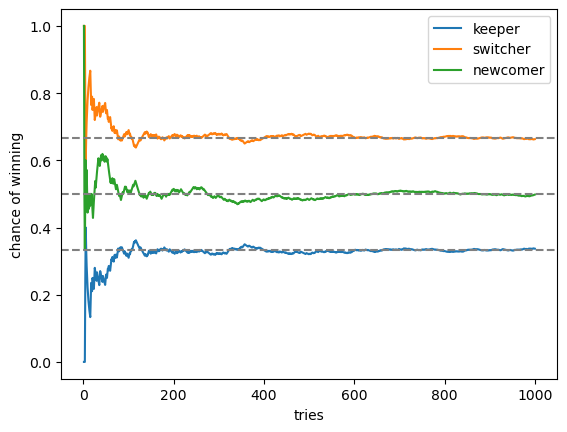

In [5]:
plt.plot(np.arange(tries)+1, keep, label = 'keeper')
plt.plot(np.arange(tries)+1, switch, label = 'switcher')
plt.plot(np.arange(tries)+1, new, label = 'newcomer')
plt.legend()
plt.ylabel('chance of winning')
plt.xlabel('tries')
for y in [1/3,1/2,2/3]:
    plt.axhline(y, ls='--',c='grey')

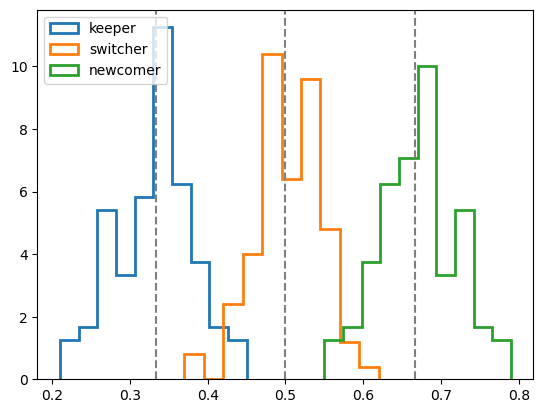

In [6]:
k_hist  = np.zeros(100)
n_hist  = np.zeros(100)
s_hist   = np.zeros(100)

for i in range(100):
    k_temp, n_temp, s_temp = MontyHall(100,3,1)
    k_hist[i] = k_temp[100-1]
    s_hist[i] = s_temp[100-1]
    n_hist[i] = n_temp[100-1]


plt.hist(k_hist,density=True, histtype='step',lw=2, label = 'keeper')
plt.hist(s_hist,density=True,histtype='step',lw=2, label = 'switcher')
plt.hist(n_hist,density=True,histtype='step',lw=2, label = 'newcomer')
plt.legend()
for x in [1/3,1/2,2/3]:
    plt.axvline(x, ls='--',c='grey')

Food for thought: And what if you had $N$ doors to choose from and the presenter opens $p \leq N$ of them? Study how the probability of winning changes as a function of $p$ and $N$. We know that:

$$
p_{\rm switch} = \frac{1}{N} \frac{N-1}{N-p-1}
$$

In [7]:
N = 53
prob_s = np.zeros(N-3)

for p in range(1,N-2):
    _, s_temp, _ = MontyHall(1000,N,p)
    prob_s[p-1] = s_temp[-1]

p_switch = lambda opd: (N-1)/(N*(N-opd-1))

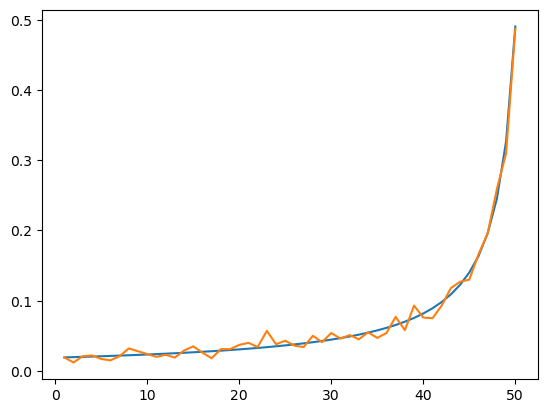

In [8]:
o_doors = np.arange(1, N-2,1)
plt.plot(o_doors, p_switch(o_doors))
plt.plot(o_doors, prob_s)

In the other extreme: if the hosts opens all losing doors but one ($p = N-2$), the advantage increases as N grows large: 

$$
p_{switch}=\frac{N-1}{N}
$$

In [9]:
nmax = 100
prob_sw = []
for n in range(3, nmax):
    _, s_temp, _ = MontyHall(1000,n,n-2)
    prob_sw.append(s_temp[-1])

p_sw = lambda d: (d-1)/d

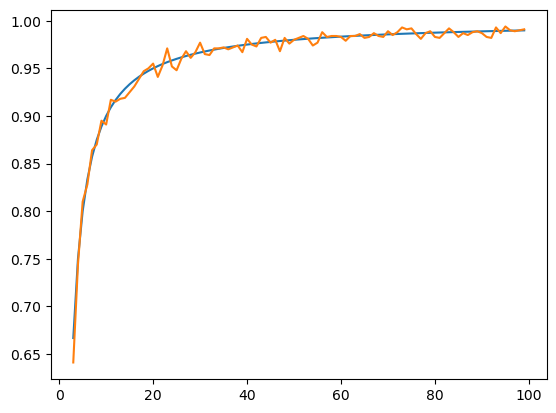

In [10]:
n_doors = np.arange(3, nmax,1)
plt.plot(n_doors, p_sw(n_doors))
plt.plot(n_doors, prob_sw)